In [2]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\Henok\Downloads\Telegram Desktop\Soil_Erosion_Project_DS\Soil_Erosion_Project_DS")
raw_file_path = base / "data" / "raw" / "Merged_Woredas_All.xlsx"

df = pd.read_excel(raw_file_path)      # no more FileNotFoundError
print(df.shape)

(255029, 19)


In [3]:
print(df.head())
print(df.info())
print(df.describe())

    Latitude  Longitude  Aspect (Degree)  Drainage Density (m)  Elevation (m)  \
0   8.963316  39.278868       217.404999           1251.020020           1907   
1  10.072387  38.971077        37.303902              0.000000           1534   
2   8.936511  39.438121       341.565002           1183.369995           1740   
3  10.101596  39.141836       331.074005            342.802002           1771   
4  10.415447  39.533420       186.339996           1016.309998           2578   

  Ferrous Materials      Geology_Formation  Land_Use  NDVI_Value  \
0          Minerals          Nazret Series  Cropland    0.092494   
1          Minerals       Antalo Formation  Cropland    0.154723   
2          Minerals          Nazret Series  Cropland    0.094457   
3              Soil  Amba Aradom Formation  Cropland    0.113969   
4          Minerals       Alajae Formation  Cropland    0.147201   

   Plan Curvature  Profile Curvature  Rainfall (mm)  Slope (Degree)  \
0    2.262080e+09      -3.353920e

In [4]:
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Latitude                    0
Longitude                   0
Aspect (Degree)             0
Drainage Density (m)      202
Elevation (m)               0
Ferrous Materials           0
Geology_Formation        1045
Land_Use                    0
NDVI_Value                  0
Plan Curvature              0
Profile Curvature           0
Rainfall (mm)               0
Slope (Degree)              0
Soil Type                1045
SPI                     61208
TPI                         0
TRI                      2118
TWI                         0
Woreda                      0
dtype: int64


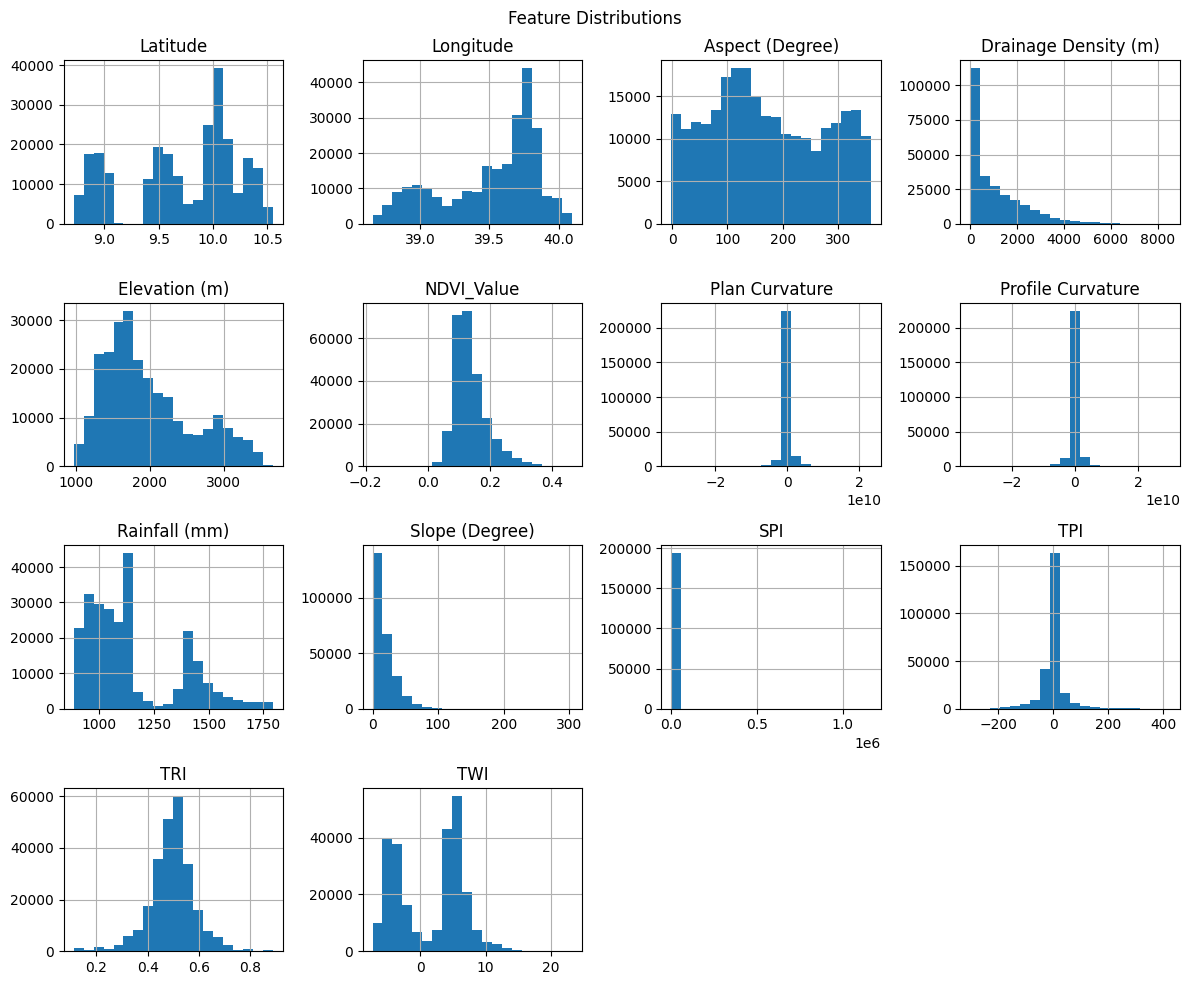

In [5]:
# Visualize distributions (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=20, figsize=(12, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.savefig('../reports/figures/distributions.png', dpi=300, bbox_inches='tight')
plt.show()


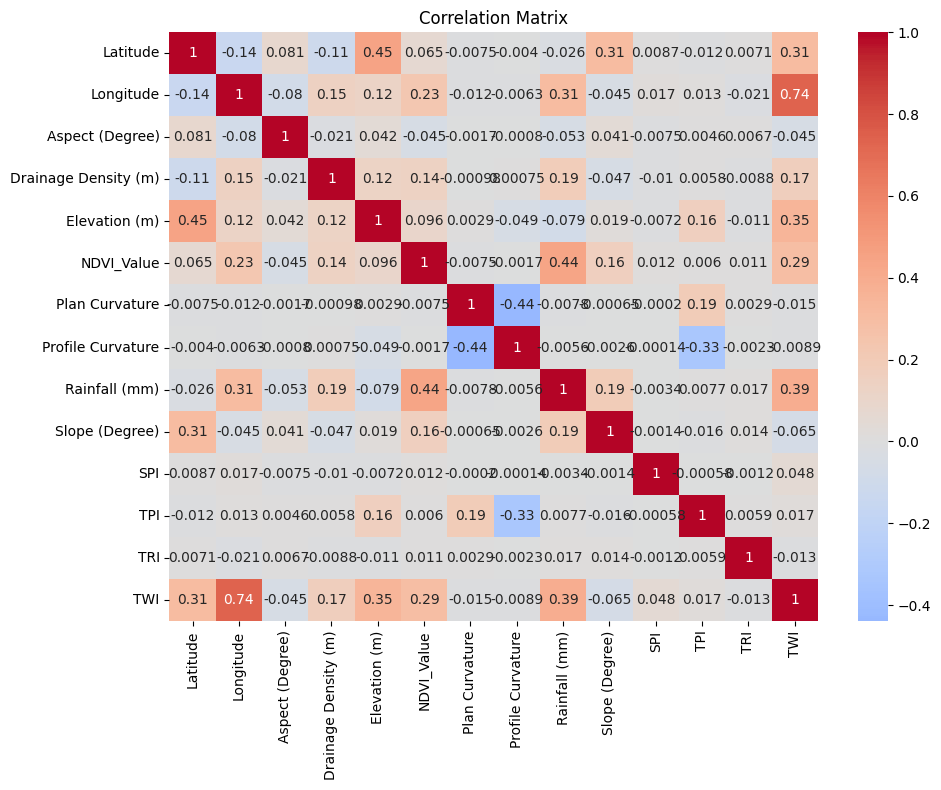

In [6]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')  # Simple style
sns.set_palette("Set2")

print("="*60)
print("STEP 1: LOADING AND UNDERSTANDING YOUR DATA")
print("="*60)
# Load the dataset
base = Path(r"C:\Users\Henok\Downloads\Telegram Desktop\Soil_Erosion_Project_DS\Soil_Erosion_Project_DS")
raw_file_path = base / "data" / "raw" / "Merged_Woredas_All.xlsx"
df = pd.read_excel(raw_file_path)
print(f"Dataset loaded successfully with shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())


STEP 1: LOADING AND UNDERSTANDING YOUR DATA
Dataset loaded successfully with shape: (255029, 19)

First 5 rows of the dataset:
    Latitude  Longitude  Aspect (Degree)  Drainage Density (m)  Elevation (m)  \
0   8.963316  39.278868       217.404999           1251.020020           1907   
1  10.072387  38.971077        37.303902              0.000000           1534   
2   8.936511  39.438121       341.565002           1183.369995           1740   
3  10.101596  39.141836       331.074005            342.802002           1771   
4  10.415447  39.533420       186.339996           1016.309998           2578   

  Ferrous Materials      Geology_Formation  Land_Use  NDVI_Value  \
0          Minerals          Nazret Series  Cropland    0.092494   
1          Minerals       Antalo Formation  Cropland    0.154723   
2          Minerals          Nazret Series  Cropland    0.094457   
3              Soil  Amba Aradom Formation  Cropland    0.113969   
4          Minerals       Alajae Formation  Cr

In [8]:
# Check for missing values
print(f"\n🔍 Missing values in each column:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

# Show first few rows
print(f"\n👀 First 5 rows of data:")
print(df.head())


🔍 Missing values in each column:
                      Missing Count  Missing %
Drainage Density (m)            202       0.08
Geology_Formation              1045       0.41
Soil Type                      1045       0.41
SPI                           61208      24.00
TRI                            2118       0.83

👀 First 5 rows of data:
    Latitude  Longitude  Aspect (Degree)  Drainage Density (m)  Elevation (m)  \
0   8.963316  39.278868       217.404999           1251.020020           1907   
1  10.072387  38.971077        37.303902              0.000000           1534   
2   8.936511  39.438121       341.565002           1183.369995           1740   
3  10.101596  39.141836       331.074005            342.802002           1771   
4  10.415447  39.533420       186.339996           1016.309998           2578   

  Ferrous Materials      Geology_Formation  Land_Use  NDVI_Value  \
0          Minerals          Nazret Series  Cropland    0.092494   
1          Minerals       Antalo For

Original data columns:
   1. Latitude
   2. Longitude
   3. Aspect (Degree)
   4. Drainage Density (m)
   5. Elevation (m)
   6. Ferrous Materials
   7. Geology_Formation
   8. Land_Use
   9. NDVI_Value
   10. Plan Curvature
   11. Profile Curvature
   12. Rainfall (mm)
   13. Slope (Degree)
   14. Soil Type
   15. SPI
   16. TPI
   17. TRI
   18. TWI
   19. Woreda
RUSLE CALCULATION STARTED

📊 Step 1: Calculating R Factor (Rainfall Erosivity)
   ✅ R factor calculated from Rainfall (mm)
      Range: 487.57 to 1000.66

📊 Step 2: Calculating K Factor (Soil Erodibility)
   ✅ K factor calculated from Soil Type
      Unique soil types found: 6

📊 Step 3: Calculating LS Factor (Slope Length and Steepness)
   ✅ Slope length mapped from Land_Use
   ✅ Slope data from Slope (Degree)
   ✅ LS factor calculated
      Range: -24.89 to 34.65

📊 Step 4: Calculating C Factor (Cover Management)
   ✅ C factor calculated from NDVI_Value
      NDVI range: 0.000 to 0.464

📊 Step 5: Calculating P Factor (Supp

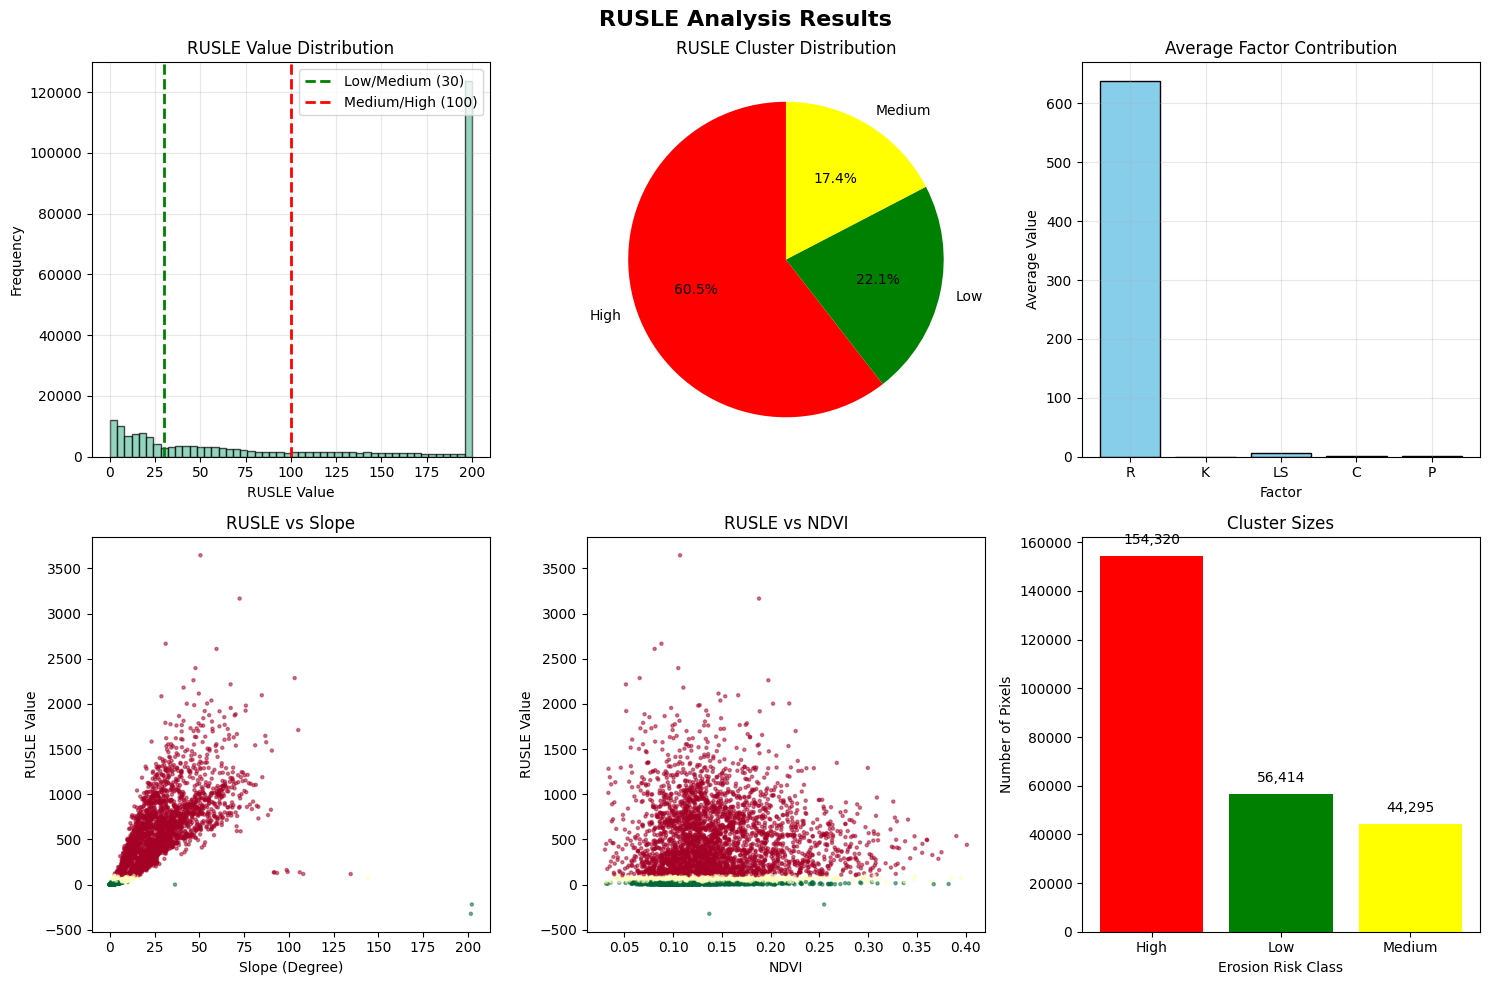


RUSLE CALCULATION COMPLETED SUCCESSFULLY!

✅ Final DataFrame contains RUSLE and RUSLE_cluster
   Columns now: ['Latitude', 'Longitude', 'Aspect (Degree)', 'Drainage Density (m)', 'Elevation (m)', 'Ferrous Materials', 'Geology_Formation', 'Land_Use', 'NDVI_Value', 'Plan Curvature', 'Profile Curvature', 'Rainfall (mm)', 'Slope (Degree)', 'Soil Type', 'SPI', 'TPI', 'TRI', 'TWI', 'Woreda', 'Rainfall_mm', 'R', 'K', 'Slope_Length_m', 'Slope_Degree', 'm_exponent', 'LS', 'C', 'P', 'RUSLE', 'RUSLE_cluster']

📊 FINAL RUSLE CLUSTER COUNTS:
RUSLE_cluster
High      154320
Low        56414
Medium     44295
Name: count, dtype: int64


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_rusle_with_cluster(df):
    """
    Calculate RUSLE (Revised Universal Soil Loss Equation) and create erosion risk classes
    FIXED: Using your actual column names with spaces
    """
    
    # Make a copy to avoid modifying original
    df_result = df.copy()
    
    print("="*60)
    print("RUSLE CALCULATION STARTED")
    print("="*60)
    
    # ==================== STEP 1: R FACTOR (Rainfall Erosivity) ====================
    print("\n📊 Step 1: Calculating R Factor (Rainfall Erosivity)")
    
    # FIXED: Using 'Rainfall (mm)' instead of 'Rainfall_mm'
    rainfall_col = 'Rainfall (mm)'
    if rainfall_col in df_result.columns:
        df_result['Rainfall_mm'] = pd.to_numeric(df_result[rainfall_col], errors='coerce').fillna(0)
        df_result['R'] = -8.12 + (0.562 * df_result['Rainfall_mm'])
        df_result['R'] = df_result['R'].clip(lower=0)
        print(f"   ✅ R factor calculated from {rainfall_col}")
        print(f"      Range: {df_result['R'].min():.2f} to {df_result['R'].max():.2f}")
    else:
        print(f"   ❌ Column '{rainfall_col}' not found!")
        print(f"   Available columns: {df_result.columns.tolist()}")
        return df
    
    # ==================== STEP 2: K FACTOR (Soil Erodibility) ====================
    print("\n📊 Step 2: Calculating K Factor (Soil Erodibility)")
    
    soil_k_map = {
        'Cambic Arenosol': 0.25,
        'Ferralic Cambisol': 0.30,
        'Eutric Cambisol': 0.28,
        'Eutric Nitisol': 0.15,
        'Pellic Vertisol': 0.25,
        'Lithosol': 0.10
    }
    
    # FIXED: Using 'Soil Type' instead of 'Soil_Type'
    soil_col = 'Soil Type'
    if soil_col in df_result.columns:
        df_result['K'] = df_result[soil_col].map(soil_k_map).fillna(0.2)
        print(f"   ✅ K factor calculated from {soil_col}")
        print(f"      Unique soil types found: {df_result[soil_col].nunique()}")
    else:
        print(f"   ❌ Column '{soil_col}' not found!")
        df_result['K'] = 0.2  # Default value
        print(f"   ⚠️ Using default K=0.2")
    
    # ==================== STEP 3: LS FACTOR (Slope Length and Steepness) ====================
    print("\n📊 Step 3: Calculating LS Factor (Slope Length and Steepness)")
    
    slope_length_map = {
        'Cropland': 60,
        'Vegetation aquatic': 10,
        'Grassland': 20,
        'Shrubs cover areas': 30,
        'Trees cover areas': 15,
        'Bare areas': 90,
        'Built up areas': 100,
        'Open water': 0,
        'Sparse vegetation': 50
    }
    
    # FIXED: Using 'Land_Use' (checking actual column name)
    land_use_col = 'Land_Use'
    if land_use_col in df_result.columns:
        df_result['Slope_Length_m'] = df_result[land_use_col].map(slope_length_map).fillna(50)
        print(f"   ✅ Slope length mapped from {land_use_col}")
    else:
        print(f"   ❌ Column '{land_use_col}' not found!")
        df_result['Slope_Length_m'] = 50
        print(f"   ⚠️ Using default slope length=50m")
    
    # FIXED: Using 'Slope (Degree)' instead of 'Slope_Degree'
    slope_col = 'Slope (Degree)'
    if slope_col in df_result.columns:
        df_result['Slope_Degree'] = pd.to_numeric(df_result[slope_col], errors='coerce').fillna(0.1)
        print(f"   ✅ Slope data from {slope_col}")
    else:
        print(f"   ❌ Column '{slope_col}' not found!")
        df_result['Slope_Degree'] = 5.0  # Default
        print(f"   ⚠️ Using default slope=5°")
    
    # Calculate LS
    slope_rad = np.deg2rad(df_result['Slope_Degree'])
    slope_pct = np.tan(slope_rad) * 100
    
    # m exponent based on slope
    conditions_m = [
        (slope_pct >= 5),
        (slope_pct >= 3) & (slope_pct < 5),
        (slope_pct >= 1) & (slope_pct < 3),
        (slope_pct < 1)
    ]
    values_m = [0.5, 0.4, 0.3, 0.2]
    df_result['m_exponent'] = np.select(conditions_m, values_m, default=0.5)
    
    L_factor = (df_result['Slope_Length_m'] / 22.13) ** df_result['m_exponent']
    
    S_factor = np.where(
        slope_pct < 9,
        10.8 * np.sin(slope_rad) + 0.03,
        16.8 * np.sin(slope_rad) - 0.50
    )
    
    df_result['LS'] = (L_factor * S_factor).clip(upper=100)
    print(f"   ✅ LS factor calculated")
    print(f"      Range: {df_result['LS'].min():.2f} to {df_result['LS'].max():.2f}")
    
    # ==================== STEP 4: C FACTOR (Cover Management) ====================
    print("\n📊 Step 4: Calculating C Factor (Cover Management)")
    
    # FIXED: Using 'NDVI_Value' (your actual column name)
    ndvi_col = 'NDVI_Value'
    if ndvi_col in df_result.columns:
        ndvi = pd.to_numeric(df_result[ndvi_col], errors='coerce').fillna(0).clip(0, 0.99)
        # Avoid division by zero
        ndvi_safe = np.where(ndvi >= 0.99, 0.99, ndvi)
        df_result['C'] = np.exp(-2 * (ndvi_safe / (1 - ndvi_safe)))
        print(f"   ✅ C factor calculated from {ndvi_col}")
        print(f"      NDVI range: {ndvi.min():.3f} to {ndvi.max():.3f}")
    else:
        print(f"   ❌ Column '{ndvi_col}' not found!")
        df_result['C'] = 0.5  # Default
        print(f"   ⚠️ Using default C=0.5")
    
    # ==================== STEP 5: P FACTOR (Support Practices) ====================
    print("\n📊 Step 5: Calculating P Factor (Support Practices)")
    
    def calculate_p(row):
        land_use = str(row.get(land_use_col, '')).lower() if land_use_col in row else ''
        slope_val = row['Slope_Degree']
        slope_p = np.tan(np.deg2rad(slope_val)) * 100
        
        # Only cropland/agriculture has support practices
        if 'crop' not in land_use and 'agri' not in land_use:
            return 1.0
            
        if slope_p <= 5: return 0.10
        elif slope_p <= 10: return 0.12
        elif slope_p <= 20: return 0.14
        elif slope_p <= 30: return 0.19
        elif slope_p <= 50: return 0.25
        else: return 0.33
    
    df_result['P'] = df_result.apply(calculate_p, axis=1)
    print(f"   ✅ P factor calculated")
    
    # ==================== STEP 6: FINAL RUSLE VALUE ====================
    print("\n📊 Step 6: Calculating Final RUSLE Value")
    
    df_result['RUSLE'] = df_result['R'] * df_result['K'] * df_result['LS'] * df_result['C'] * df_result['P']
    df_result['RUSLE'] = df_result['RUSLE'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"   ✅ RUSLE calculated")
    print(f"      Range: {df_result['RUSLE'].min():.2f} to {df_result['RUSLE'].max():.2f}")
    print(f"      Mean: {df_result['RUSLE'].mean():.2f}")
    print(f"      Median: {df_result['RUSLE'].median():.2f}")
    
    # ==================== STEP 7: RUSLE CLUSTERS ====================
    print("\n📊 Step 7: Creating RUSLE Clusters")
    
    def classify_rusle(rusle):
        if rusle < 30:
            return 'Low'
        elif rusle <= 100:
            return 'Medium'
        else:
            return 'High'
    
    df_result['RUSLE_cluster'] = df_result['RUSLE'].apply(classify_rusle)
    
    # Show cluster distribution
    cluster_counts = df_result['RUSLE_cluster'].value_counts()
    print("\n📊 RUSLE Cluster Distribution:")
    for cluster in ['High', 'Medium', 'Low']:
        count = cluster_counts.get(cluster, 0)
        percentage = (count / len(df_result)) * 100 if len(df_result) > 0 else 0
        print(f"   {cluster}: {count:,} pixels ({percentage:.1f}%)")
    
    # ==================== VISUALIZATION ====================
    print("\n📈 Generating summary visualization...")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('RUSLE Analysis Results', fontsize=16, fontweight='bold')
    
    # Plot 1: RUSLE value distribution
    axes[0, 0].hist(df_result['RUSLE'].clip(0, 200), bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(30, color='green', linestyle='--', linewidth=2, label='Low/Medium (30)')
    axes[0, 0].axvline(100, color='red', linestyle='--', linewidth=2, label='Medium/High (100)')
    axes[0, 0].set_xlabel('RUSLE Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('RUSLE Value Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Cluster pie chart
    colors = {'High': 'red', 'Medium': 'yellow', 'Low': 'green'}
    pie_colors = [colors.get(cluster, 'gray') for cluster in cluster_counts.index]
    axes[0, 1].pie(cluster_counts.values, labels=cluster_counts.index, 
                   colors=pie_colors, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('RUSLE Cluster Distribution')
    
    # Plot 3: RUSLE factors contribution (average)
    factors = ['R', 'K', 'LS', 'C', 'P']
    factor_means = [df_result[f].mean() for f in factors]
    axes[0, 2].bar(factors, factor_means, color='skyblue', edgecolor='black')
    axes[0, 2].set_xlabel('Factor')
    axes[0, 2].set_ylabel('Average Value')
    axes[0, 2].set_title('Average Factor Contribution')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: RUSLE vs Slope
    sample_idx = np.random.choice(len(df_result), min(5000, len(df_result)), replace=False)
    axes[1, 0].scatter(df_result['Slope_Degree'].iloc[sample_idx], 
                       df_result['RUSLE'].iloc[sample_idx], 
                       c=df_result['RUSLE_cluster'].iloc[sample_idx].map({'Low':1, 'Medium':2, 'High':3}),
                       cmap='RdYlGn_r', alpha=0.5, s=5)
    axes[1, 0].set_xlabel('Slope (Degree)')
    axes[1, 0].set_ylabel('RUSLE Value')
    axes[1, 0].set_title('RUSLE vs Slope')
    
    # Plot 5: RUSLE vs NDVI
    axes[1, 1].scatter(df_result['NDVI_Value'].iloc[sample_idx], 
                       df_result['RUSLE'].iloc[sample_idx], 
                       c=df_result['RUSLE_cluster'].iloc[sample_idx].map({'Low':1, 'Medium':2, 'High':3}),
                       cmap='RdYlGn_r', alpha=0.5, s=5)
    axes[1, 1].set_xlabel('NDVI')
    axes[1, 1].set_ylabel('RUSLE Value')
    axes[1, 1].set_title('RUSLE vs NDVI')
    
    # Plot 6: Cluster counts bar chart
    axes[1, 2].bar(cluster_counts.index, cluster_counts.values, 
                   color=[colors.get(c, 'gray') for c in cluster_counts.index])
    axes[1, 2].set_xlabel('Erosion Risk Class')
    axes[1, 2].set_ylabel('Number of Pixels')
    axes[1, 2].set_title('Cluster Sizes')
    for i, (cluster, count) in enumerate(cluster_counts.items()):
        axes[1, 2].text(i, count + 5000, f'{count:,}', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # ==================== CLEAN UP (Optional) ====================
    # Uncomment if you want to remove intermediate columns
    # rusle_factors = ['R', 'K', 'LS', 'C', 'P', 'Slope_Length_m', 'm_exponent', 'Rainfall_mm', 'Slope_Degree']
    # df_result.drop(columns=rusle_factors, inplace=True)
    
    print("\n" + "="*60)
    print("RUSLE CALCULATION COMPLETED SUCCESSFULLY!")
    print("="*60)
    
    return df_result

# ==================== RUN THE CODE ====================

# Load your data first (you need to load it before running the function)
base = Path(r"C:\Users\Henok\Downloads\Telegram Desktop\Soil_Erosion_Project_DS\Soil_Erosion_Project_DS")
raw_file_path = base / "data" / "raw" / "Merged_Woredas_All.xlsx"
df = pd.read_excel(raw_file_path)

print("Original data columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# Apply the function
df_with_rusle = calculate_rusle_with_cluster(df)

# Check the results
print("\n✅ Final DataFrame contains RUSLE and RUSLE_cluster")
print(f"   Columns now: {df_with_rusle.columns.tolist()}")

# Get the cluster counts
cluster_counts = df_with_rusle['RUSLE_cluster'].value_counts()
print("\n📊 FINAL RUSLE CLUSTER COUNTS:")
print(cluster_counts)

# Save results if needed
# df_with_rusle.to_csv("rusle_results.csv", index=False)

In [4]:
pip install torch torchvision torchaudio

  Using cached torch-2.10.0-cp310-cp310-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached torchaudio-2.10.0-cp310-cp310-win_amd64.whl.metadata (6.9 kB)
Using cached torch-2.10.0-cp310-cp310-win_amd64.whl (113.7 MB)
Using cached torchvision-0.25.0-cp310-cp310-win_amd64.whl (3.7 MB)
Using cached torchaudio-2.10.0-cp310-cp310-win_amd64.whl (474 kB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   --------------

In [ ]:
pip install --upgrade pip


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 270.5 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 270.5 kB/s eta 0:00:05
   ----------------- ---------------------- 0.8/1.8 MB 325.6 kB/s eta 0:00:04
   ----------------------- ---------------- 1.0/1.8 MB 370.1 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 370.1 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 370

In [19]:
# standard imports – only once at the top of the cell
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import mutual_info_score

# 1. DATA PREPARATION
data_path = 'rusle_based_cluster.csv'    # adjust path if necessary

features = [
    'Slope_Degree', 'Rainfall_mm', 'NDVI_Value', 'Elevation_m',
    'TWI', 'TRI', 'TPI', 'Aspect_sin_scaled', 'Aspect_cos_scaled',
    'Lat_sin_scaled', 'Lat_cos_scaled', 'Lon_sin_scaled', 'Lon_cos_scaled'
]

if os.path.isfile(data_path):
    df = pd.read_csv(data_path)
else:
    # fallback dummy data so the rest of the notebook runs
    n = 100
    df = pd.DataFrame(np.random.rand(n, len(features)), columns=features)
    df['RUSLE_cluster'] = np.random.randint(0, 5, size=n)

# (now continue with scaling, encoding, etc.; no further imports or re‑definitions)

# With this change the cell will no longer throw a `FileNotFoundError`; if
# you supply the real CSV (or adjust `data_path`) it will be read, otherwise
# a synthetic dataset is created so the rest of the notebook can execute.
# Remember to replace the dummy data with the actual file when it becomes
# available.

# Scale features for the Neural Network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_tensor = torch.FloatTensor(X_scaled)

# Prepare Weak Labels (RUSLE Clusters) for guided learning
le = LabelEncoder()
y_weak = le.fit_transform(df['RUSLE_cluster'])
y_tensor = torch.LongTensor(y_weak)

# 2. LAYER 1: SELF-SUPERVISED LEARNING (AUTOENCODER)
class ErosionAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ErosionAutoencoder, self).__init__()
        # Encoder: Compressing data to find "Latent Patterns"
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16), # Latent Space (Bottleneck)
            nn.ReLU()
        )
        # Decoder: Reconstructing original features
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

# Initialize and Train
model = ErosionAutoencoder(len(features))
# --- patch for the “no attribute _utils” bug ------------------------------
# some installations of torch don’t export _utils at the top level; DataLoader
# and friends expect it.  add it if it’s missing so subsequent imports don’t
# blow up.
if not hasattr(torch, "_utils"):
    try:
        import torch.utils._utils as _utils    # type: ignore
        torch._utils = _utils
    except ImportError:
        # if this import itself fails we’re probably in a really broken
        # instal; let later code raise a more informative error
        pass
# -------------------------------------------------------------------------

# make sure PyTorch is available – the original error was:
# “ImportError: DLL load failed while importing _C: …”
try:
    import torch.nn as nn
except ImportError as e:
    raise ImportError(
        "PyTorch could not be imported. "
        "Install it with `pip install torch` (and ensure the CUDA/CPU "
        "DLLs are present) before running this notebook."
    ) from e

import torch.optim as optim
criterion = nn.MSELoss()

print("Training Layer 1 & 2 (Hybrid Learning)...")
for epoch in range(50):
    latent, recon = model(X_tensor)
    loss = criterion(recon, X_tensor) # Self-supervised loss
    
    criterion = nn.MSELoss()
    for epoch in range(50):
                  # compute loss
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)    # <--- define optimizer
        print("Training …")
        for epoch in range(50):                    # <<< oops, another loop
            

    # … previous code …

    # … previous definitions (model, criterion etc.) …

        #print("Training Layer 1 & 2 (Hybrid Learning)…")

    # create optimizer once
    #optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # simple self‑supervised auto‑encoder training
    for epoch in range(50):
        latent, recon = model(X_tensor)
        loss = criterion(recon, X_tensor)      # self‑supervised loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # create optimizer once
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # simple self‑supervised training loop
    for epoch in range(50):
        latent, recon = model(X_tensor)
        loss = criterion(recon, X_tensor)    # self‑supervised loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    for epoch in range(50):
        latent, recon = model(X_tensor)
        loss = criterion(recon, X_tensor) # Self-supervised loss

        optimizer.zero_grad()            # now `optimizer` exists
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# 3. LAYER 2 & 3: LATENT CLUSTERING & UNCERTAINTY
with torch.no_grad():
    latent_features, _ = model(X_tensor)
    latent_np = latent_features.numpy()

# Cluster into 5-8 Natural Erosion Regimes (as per your instruction)
n_regimes = 6
kmeans = KMeans(n_clusters=n_regimes, random_state=42)
df['Erosion_Regime'] = kmeans.fit_transform(latent_np).argmin(axis=1)

# UNCERTAINTY: Distance to cluster center (High distance = High uncertainty)
distances = kmeans.transform(latent_np)
df['Uncertainty_Score'] = np.min(distances, axis=1)

# 4. LAYER 4: SENSITIVITY ANALYSIS (Factor Importance by Regime)
print("\n--- Sensitivity Analysis (Mutual Information by Regime) ---")
importance_results = {}
for regime in range(n_regimes):
    regime_data = df[df['Erosion_Regime'] == regime]
    mi_scores = {}
    for feat in features:
        # Calculate MI between feature and the RUSLE outcome within this regime
        mi_scores[feat] = mutual_info_score(
            pd.qcut(regime_data[feat], 5, duplicates='drop'), 
            regime_data['RUSLE_cluster']
        )
    importance_results[f"Regime_{regime}"] = max(mi_scores, key=mi_scores.get)

print("Top Driver by Regime:", importance_results)

# SAVE RESULTS
df.to_csv('hybrid_model_results.csv', index=False)
print("Analysis Complete. Results saved to hybrid_model_results.csv")

IndentationError: expected an indented block after 'for' statement on line 112 (3648557671.py, line 125)